In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell A — Imports & Configuration (v11)
# Changes vs v10:
#   • S_DIM=6: structure matrix cols [M31, M32, M41, M42, M43, degree]
#   • LAG_STEPS=2: temporal lag features concatenated to X_t
#   • TRADE_THRESH_PCTILE=25: percentile to binarise trade for adjacency/motifs
#   • GUIDEEdgeFlowAE removed; proper GUIDE (S+X) and DOMINANT (X+A) in Cell G
#   • ALPHA kept at 0.2 (paper optimal range 0.1–0.3)
# ══════════════════════════════════════════════════════════════════════════════

import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

try:
    import networkx as nx
    HAS_NX = True
    print("✓ NetworkX available")
except ImportError:
    HAS_NX = False
    print("✗ NetworkX not found — pip install networkx")

try:
    from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv
    from torch_geometric.nn import MessagePassing
    from torch_geometric.utils import softmax as pyg_softmax, add_self_loops
    HAS_PYG = True
    print("✓ PyTorch Geometric available")
except ImportError:
    HAS_PYG = False
    print("✗ PyTorch Geometric not found")

warnings.filterwarnings("ignore", category=UserWarning)

# ── Canonical configuration ────────────────────────────────────────────────────
START_MONTH = "2014-01"
END_MONTH   = "2025-11"
MONTHLY_IDX = pd.date_range(START_MONTH, END_MONTH, freq="MS")

COUNTRIES = [
    "AT","BE","BG","CY","CZ","DE","DK","EE","EL",
    "ES","FI","FR","HR","HU","IE","IT","LT","LU",
    "LV","MT","NL","PL","PT","RO","SE","SI","SK",
]
COUNTRY_IDX = {c: i for i, c in enumerate(COUNTRIES)}
N = len(COUNTRIES)   # 27

ALL_CATS = [
    "TOTAL", "Food_drinks_tobacco", "Raw_materials",
    "Energy", "Chemicals", "Machinery_vehicles", "Other_manufactured",
]
N_CATS = len(ALL_CATS)   # 7

CEPII_COLS = [
    "comlang_ethno", "contig", "smctry",
    "dist", "distcap", "distw", "distwces"
]

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR      = Path("C:/Users/diede/Downloads/FILES FROM FULL DATA PIPELINE RUN")
MAIN_DATA_DIR = DATA_DIR / "main_data"
NODE_DIR      = DATA_DIR / "NodeFeatures" / "Second Try"
EDGE_DIR      = DATA_DIR / "edge_features"
GRAPH_DIR     = DATA_DIR / "graph_features"
IMPUTED_TRADE_CSV = MAIN_DATA_DIR / "eu_intra_trade_sitc_imputed.csv"

# ── Model hyperparameters ──────────────────────────────────────────────────────
HIDDEN_DIM  = 128
N_EPOCHS    = 100
LR          = 3e-4
GRAD_CLIP   = 1.0
HEADS       = 4
K_NEIGHBORS = 6
LOG_NODE_FEATURES = True

# ── GUIDE faithful implementation ──────────────────────────────────────────────
ALPHA          = 0.2    # weight on attribute branch; paper optimal 0.1–0.3
RECON_EPOCHS   = N_EPOCHS
ANOMALY_THRESH = 3.0

# ── v11 additions ─────────────────────────────────────────────────────────────
S_DIM               = 6    # motif feature dims: M31, M32, M41, M42, M43, degree
LAG_STEPS           = 2    # number of historical timesteps to concat to X_t
TRADE_THRESH_PCTILE = 25   # percentile threshold for binary trade adjacency

# ── Anomaly injection (unchanged from v10) ────────────────────────────────────
SPIKE_MULT  = 30.0
CRASH_MULT  = 0.02
N_PER_TYPE  = 150

SEED    = 42
SEQ_LEN = 6

TRAIN_END = pd.Timestamp("2019-12-01")
VAL_END   = pd.Timestamp("2023-12-01")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device       : {DEVICE}")
print(f"Monthly index: {MONTHLY_IDX[0].date()} → {MONTHLY_IDX[-1].date()} ({len(MONTHLY_IDX)} periods)")
print(f"Countries    : {N} | Categories: {N_CATS} | Directed edges: {N * (N - 1)}")
print(f"N_EPOCHS={N_EPOCHS}  HIDDEN_DIM={HIDDEN_DIM}  ALPHA={ALPHA}  "
      f"S_DIM={S_DIM}  LAG_STEPS={LAG_STEPS}")


✓ NetworkX available
✓ PyTorch Geometric available
Device       : cpu
Monthly index: 2014-01-01 → 2025-11-01 (143 periods)
Countries    : 27 | Categories: 7 | Directed edges: 702
N_EPOCHS=100  HIDDEN_DIM=128  ALPHA=0.2  S_DIM=6  LAG_STEPS=2


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell B — Load All CSVs  (unchanged from v10)
# ══════════════════════════════════════════════════════════════════════════════

df_trade = pd.read_csv(IMPUTED_TRADE_CSV)
df_trade["time"] = pd.to_datetime(df_trade["time"])
print(f"── Trade CSV ──")
print(f"  Shape      : {df_trade.shape}")
print(f"  Time range : {df_trade['time'].min().date()} → {df_trade['time'].max().date()}")
assert df_trade.isna().sum().sum() == 0, "NaNs in trade CSV!"
print(f"  NaNs       : 0 ✓\n")

node_csv_paths = sorted(NODE_DIR.glob("*.csv"))
assert node_csv_paths, f"No node CSVs found in {NODE_DIR}"
node_dfs = {}
for p in node_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    node_dfs[p.stem] = df
total_node_nans = sum(df.isna().sum().sum() for df in node_dfs.values())
assert total_node_nans == 0, f"Found {total_node_nans} NaNs in node features!"
print(f"── Node CSVs: {len(node_dfs)} files, 0 NaNs ✓")

graph_csv_paths = sorted(GRAPH_DIR.glob("*.csv"))
graph_series = {}
for p in graph_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    graph_series[p.stem] = df.iloc[:, 0].rename(p.stem)
print(f"── Graph CSVs: {list(graph_series.keys())}")

edge_csv = EDGE_DIR / "eu27_bilateral_static_features.csv"
df_edge = pd.read_csv(edge_csv)
df_edge["time"] = pd.to_datetime(df_edge["time"])
print(f"── Edge CSV : {df_edge.shape}  cols={list(df_edge.columns)}")


── Trade CSV ──
  Shape      : (100262, 10)
  Time range : 2014-01-01 → 2025-11-01
  NaNs       : 0 ✓

── Node CSVs: 35 files, 0 NaNs ✓
── Graph CSVs: ['euribor3m_monthly', 'vstoxx_monthly']
── Edge CSV : (100386, 11)  cols=['Unnamed: 0', 'time', 'reporter', 'partner', 'comlang_ethno', 'contig', 'smctry', 'dist', 'distcap', 'distw', 'distwces']


In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell C — Tensor Assembly  (unchanged from v10)
# ══════════════════════════════════════════════════════════════════════════════

common_time = MONTHLY_IDX
for stem, df in node_dfs.items():
    common_time = common_time.intersection(df.index)
for stem, s in graph_series.items():
    common_time = common_time.intersection(s.index)
trade_times = pd.DatetimeIndex(sorted(df_trade["time"].unique()))
common_time = common_time.intersection(trade_times)
T = len(common_time)
print(f"Common time range: {common_time[0].date()} → {common_time[-1].date()}  (T={T})")

node_arrays, node_feat_names = [], []
for stem, df in sorted(node_dfs.items()):
    arr = df.loc[common_time, COUNTRIES].values.astype(np.float32)
    node_arrays.append(arr)
    node_feat_names.append(stem)
node_np_raw = np.stack(node_arrays, axis=-1)
F_node = node_np_raw.shape[2]

graph_feat_names = sorted(graph_series.keys())
graph_np = np.stack(
    [graph_series[s].reindex(common_time).values.astype(np.float32) for s in graph_feat_names],
    axis=-1,
)
graph_broadcast    = np.repeat(graph_np[:, np.newaxis, :], N, axis=1)
node_plus_graph_np = np.concatenate([node_np_raw, graph_broadcast], axis=-1)
F_total = node_plus_graph_np.shape[2]

edge_pairs = [(i, j) for i in range(N) for j in range(N) if i != j]
E      = len(edge_pairs)
src_idx = [p[0] for p in edge_pairs]
dst_idx = [p[1] for p in edge_pairs]

target_np_raw = np.full((T, N, N, N_CATS), np.nan, dtype=np.float32)
for t_idx, ts in enumerate(common_time):
    df_t = df_trade[df_trade["time"] == ts]
    for _, row in df_t.iterrows():
        ri = COUNTRY_IDX.get(row["reporter"])
        pi = COUNTRY_IDX.get(row["partner"])
        if ri is not None and pi is not None and ri != pi:
            target_np_raw[t_idx, ri, pi, :] = [row[c] for c in ALL_CATS]
target_edge_np = target_np_raw[:, src_idx, dst_idx, :]

F_edge = len(CEPII_COLS)
df_edge_t0   = df_edge[df_edge["time"] == df_edge["time"].min()].copy()
edge_feat_map = {}
for _, row in df_edge_t0.iterrows():
    ri = COUNTRY_IDX.get(row["reporter"])
    pi = COUNTRY_IDX.get(row["partner"])
    if ri is not None and pi is not None and ri != pi:
        edge_feat_map[(ri, pi)] = [row[c] for c in CEPII_COLS]
edge_feat_np = np.zeros((E, F_edge), dtype=np.float32)
for e_idx, (i, j) in enumerate(edge_pairs):
    if (i, j) in edge_feat_map:
        edge_feat_np[e_idx] = edge_feat_map[(i, j)]

node_feat_tensor = torch.tensor(node_plus_graph_np, dtype=torch.float32)
edge_feat_tensor = torch.tensor(edge_feat_np,       dtype=torch.float32)
target_tensor    = torch.tensor(target_edge_np,     dtype=torch.float32)

print(f"✓ node_feat_tensor: {node_feat_tensor.shape}")
print(f"  edge_feat_tensor: {edge_feat_tensor.shape}")
print(f"  target_tensor   : {target_tensor.shape}")


Common time range: 2014-01-01 → 2025-11-01  (T=143)
✓ node_feat_tensor: torch.Size([143, 27, 37])
  edge_feat_tensor: torch.Size([702, 7])
  target_tensor   : torch.Size([143, 702, 7])


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell D — Normalisation, Trade Adjacency, Structure Matrix & Lag Features (v11)
#
# v11 additions vs v10:
#   1. Per-timestep binary trade adjacency A_bin_series from TOTAL flows
#   2. Structure matrix S ∈ R^{T×N×6} via exact node motif degrees
#      [M31=triangle, M32=wedge, M41=K4, M42=K4-edge, M43=4-cycle, degree]
#   3. Temporal lag features: node input becomes [X_t || X_{t-1} || X_{t-2}]
#      giving the GNN memory of recent trade states (addresses static-graph flaw)
# ══════════════════════════════════════════════════════════════════════════════

train_idx = [t for t in range(len(common_time)-1) if common_time[t+1] <= TRAIN_END]
val_idx   = [t for t in range(len(common_time)-1) if TRAIN_END < common_time[t+1] <= VAL_END]
test_idx  = [t for t in range(len(common_time)-1) if common_time[t+1] > VAL_END]

n_train = len(train_idx)
n_val   = len(val_idx)
n_test  = len(test_idx)

print(f"Train {n_train} | Val {n_val} (monitoring only) | Test {n_test} (evaluation) ✓")
print(f"  Train : {common_time[train_idx[0]+1].date()} → {common_time[train_idx[-1]+1].date()}")
print(f"  Val   : {common_time[val_idx[0]+1].date()} → {common_time[val_idx[-1]+1].date()}")
print(f"  Test  : {common_time[test_idx[0]+1].date()} → {common_time[test_idx[-1]+1].date()}")

# ── Log + z-score normalisation of node features ──────────────────────────────
if LOG_NODE_FEATURES:
    train_min = node_feat_tensor[train_idx].reshape(-1, F_total).min(dim=0).values
    log_mask  = train_min > 0
    nf_raw    = node_feat_tensor.clone()
    nf_raw[:, :, log_mask] = torch.log1p(node_feat_tensor[:, :, log_mask])
else:
    nf_raw = node_feat_tensor

train_data = nf_raw[train_idx]
feat_mean  = train_data.mean(dim=0)
feat_std   = train_data.std(dim=0)
feat_std[feat_std < 1e-5] = 1.0
node_feat_norm = (nf_raw - feat_mean) / feat_std

DISTANCE_FEAT_COLS    = ["dist","distcap","distw","distwces"]
DISTANCE_FEAT_INDICES = [CEPII_COLS.index(c) for c in DISTANCE_FEAT_COLS]
ef = edge_feat_tensor.clone()
for ci in DISTANCE_FEAT_INDICES:
    ef[:, ci] = torch.log1p(ef[:, ci])
emin = ef.min(dim=0).values; emax = ef.max(dim=0).values
edge_feat_norm = (ef - emin) / (emax - emin).clamp(min=1e-5)

target_log   = torch.log1p(target_tensor.clamp(min=0))
valid_tr_log = target_log[train_idx][~torch.isnan(target_log[train_idx])]
TARGET_SCALE = float(valid_tr_log.quantile(0.99))
target_scaled = target_log / TARGET_SCALE
print(f"TARGET_SCALE = {TARGET_SCALE:.4f}")

def detransform(x):
    t = torch.tensor(x) if not isinstance(x, torch.Tensor) else x
    return torch.expm1(t.clamp(min=-30) * TARGET_SCALE)

target_np  = target_scaled.numpy()
node_np    = node_feat_norm.numpy()
edge_np    = edge_feat_norm.numpy()

train_tgt_t = [t+1 for t in train_idx]
val_tgt_t   = [t+1 for t in val_idx]
test_tgt_t  = [t+1 for t in test_idx]

# ── 1. Per-timestep binary trade adjacency ─────────────────────────────────────
#
# Critique Fix: "The code constructs the GNN message-passing graph using static
# geographic CEPII-KNN distances. In trade networks, the topology IS the trade flow."
# We compute a trade-flow-based binary adjacency used for motif counting and as an
# alternative message-passing topology (Trade-KNN, defined in Cell F).
#
print("\nBuilding per-timestep binary trade adjacency...")
trade_total = target_np_raw[:, :, :, 0]   # (T, N, N) TOTAL category, raw scale
positive_train_vals = trade_total[train_tgt_t][trade_total[train_tgt_t] > 0]
trade_thresh = float(np.nanpercentile(positive_train_vals, TRADE_THRESH_PCTILE))
A_bin_series = (trade_total > trade_thresh).astype(np.float32)   # (T, N, N)
for t in range(A_bin_series.shape[0]):
    np.fill_diagonal(A_bin_series[t], 0)
avg_density = A_bin_series.mean()
print(f"  Trade threshold (pctile {TRADE_THRESH_PCTILE}): {trade_thresh:.2f}")
print(f"  Avg binary adj density: {avg_density:.3f}  "
      f"({avg_density*N*(N-1):.0f} edges/timestep on avg)")

# ── 2. Structure Matrix S via Node Motif Degrees (GUIDE Definition 3) ──────────
#
# Critique Fix: "The paper explicitly defines a structure matrix S composed of
# node motif degrees (M31, M32, M41, M42, M43). The code completely ignores this."
#
# S ∈ R^{T×N×6} columns: [M31=triangle, M32=open-wedge, M41=K4,
#                          M42=K4-minus-edge, M43=4-cycle, degree]
# Binary trade graph symmetrised for undirected motif counting.

def compute_motif_degrees(A_bin_t, n):
    # Symmetrise directed trade graph to undirected for motif counting
    A_un = ((A_bin_t + A_bin_t.T) > 0).astype(bool)
    np.fill_diagonal(A_un, False)
    G = nx.from_numpy_array(A_un.astype(int))

    deg  = np.array([G.degree(i) for i in range(n)], dtype=np.float32)
    # M31: triangle count per node
    tri  = np.array([nx.triangles(G, i) for i in range(n)], dtype=np.float32)
    m31  = tri
    # M32: open wedge = C(degree,2) - triangles
    m32  = np.maximum(0.0, deg*(deg-1)/2 - tri)
    # M41 (K4), M42 (K4-minus-1-edge), M43 (4-cycle): enumerate C(n,4) subsets
    # For N=27, C(27,4)=17,550 iterations — exact and fast
    m41 = np.zeros(n, dtype=np.float32)
    m42 = np.zeros(n, dtype=np.float32)
    m43 = np.zeros(n, dtype=np.float32)
    for combo in combinations(range(n), 4):
        sub_A = A_un[np.ix_(list(combo), list(combo))]
        n_e   = int(sub_A.sum()) // 2
        d_sub = sub_A.sum(axis=1)
        if n_e == 6:                           # K4 — M41
            for v in combo: m41[v] += 1
        elif n_e == 5:                         # K4 minus 1 edge — M42
            for v in combo: m42[v] += 1
        elif n_e == 4 and (d_sub == 2).all():  # 4-cycle — M43
            for v in combo: m43[v] += 1
    return np.stack([m31, m32, m41, m42, m43, deg], axis=1)  # (n, 6)


print(f"\nComputing S matrix (T={T} timesteps, each ~17K 4-node subsets)...")
S_raw = np.zeros((T, N, S_DIM), dtype=np.float32)
for t_idx in range(T):
    S_raw[t_idx] = compute_motif_degrees(A_bin_series[t_idx], N)
    if t_idx % 24 == 0:
        print(f"  t={t_idx}/{T}", end="\r")
print(f"\n  S_raw: {S_raw.shape}  "
      f"M31={S_raw[:,:,0].mean():.2f}  M32={S_raw[:,:,1].mean():.2f}  "
      f"M41={S_raw[:,:,2].mean():.2f}  degree={S_raw[:,:,5].mean():.2f}")

# Normalise S with TRAIN statistics (z-score, node-specific)
S_train_vals = S_raw[train_tgt_t]                           # (n_train, N, 6)
S_mean = S_train_vals.mean(axis=0, keepdims=True)           # (1, N, 6)
S_std  = S_train_vals.std(axis=0, keepdims=True).clip(min=1e-5)
S_norm = (S_raw - S_mean) / S_std
S_tensor = torch.tensor(S_norm, dtype=torch.float32)
print(f"  S_tensor: {S_tensor.shape} ✓  (z-scored with TRAIN stats)")

# ── 3. Temporal Lag Features ──────────────────────────────────────────────────
#
# Critique Fix: "the code processes each month as an entirely independent,
# memoryless static graph. It completely fails to model temporal evolution."
# Concatenating X_{t-1}, X_{t-2} to X_t gives the GNN memory of recent states.
# Full recurrent approach (Graph-GRU) is a future extension.
#
lag_list = [node_feat_norm]
for lag in range(1, LAG_STEPS + 1):
    padded = torch.cat(
        [node_feat_norm[[0]].expand(lag, -1, -1),
         node_feat_norm[:-lag]], dim=0
    )
    lag_list.append(padded)
node_feat_with_lags = torch.cat(lag_list, dim=-1)   # (T, N, F_total*(1+LAG_STEPS))
F_in = node_feat_with_lags.shape[-1]
print(f"\nNode features with {LAG_STEPS} lags: {node_feat_with_lags.shape}  F_in={F_in}")
print("✓ Normalisation, adjacency, S matrix, and lag features complete")


Train 71 | Val 48 (monitoring only) | Test 23 (evaluation) ✓
  Train : 2014-02-01 → 2019-12-01
  Val   : 2020-01-01 → 2023-12-01
  Test  : 2024-01-01 → 2025-11-01
TARGET_SCALE = 21.2149

Building per-timestep binary trade adjacency...
  Trade threshold (pctile 25): 7583079.50
  Avg binary adj density: 0.742  (521 edges/timestep on avg)

Computing S matrix (T=143 timesteps, each ~17K 4-node subsets)...
  t=120/143
  S_raw: (143, 27, 6)  M31=200.43  M32=27.17  M41=1151.38  degree=21.29
  S_tensor: torch.Size([143, 27, 6]) ✓  (z-scored with TRAIN stats)

Node features with 2 lags: torch.Size([143, 27, 111])  F_in=111
✓ Normalisation, adjacency, S matrix, and lag features complete


In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell E — Synthetic Anomaly Injection (v10) — TEST SET ONLY
#
# v10 design principles:
#   1. ALL anomalies are purely artificial (no COVID/Ukraine soft labels)
#   2. Injected ONLY into the test set — train/val remain completely clean
#   3. Six diverse types covering structural AND attribute dimensions:
#        T1 Flow Spike       — multiply one (edge,cat) by SPIKE_MULT (30×)
#        T2 Flow Crash       — multiply one (edge,cat) by CRASH_MULT (0.02×)
#        T3 Trade Cessation  — zero ALL categories for one edge in one month
#        T4 Category Swap    — exchange values of two random sub-categories
#        T5 Node Attr Shock  — replace one country's features with +4σ noise;
#                               flags all edges adjacent to that node
#        T6 Direction Swap   — swap i→j and j→i flows for 3 consecutive months
#   4. Anomaly rate and cell counts printed explicitly
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(SEED)
torch.manual_seed(SEED)

# label_synth: (n_test, E, N_CATS)  bool
label_synth  = np.zeros((n_test, E, N_CATS), dtype=bool)
synth_events = []   # list of (vi, e_idx, c_idx) for visualisation

edge_pair_to_idx_E = {pair: idx for idx, pair in enumerate(edge_pairs)}

# Pre-compute node-feature training statistics for Type 5
tr_node_mean = node_feat_norm[train_idx].mean(dim=0)   # (N, F)
tr_node_std  = node_feat_norm[train_idx].std(dim=0).clamp(min=1e-5)  # (N, F)

def _attempt(n_target, sampler):
    """Run sampler() up to 10× n_target times, stop when n_target successes."""
    cnt = 0
    for _ in range(n_target * 10):
        if cnt >= n_target:
            break
        if sampler():
            cnt += 1
    return cnt

# ── Type 1: Flow Spike ────────────────────────────────────────────────────────
used_t1 = set()
def _t1():
    vi    = np.random.randint(0, n_test)
    e_idx = np.random.randint(0, E)
    c_idx = np.random.randint(0, N_CATS)
    key   = (vi, e_idx, c_idx)
    if key in used_t1: return False
    t_tgt = test_idx[vi] + 1
    orig  = float(target_scaled[t_tgt, e_idx, c_idx])
    if np.isnan(orig) or orig < 0.05: return False
    target_scaled[t_tgt, e_idx, c_idx] = orig * SPIKE_MULT
    label_synth[vi, e_idx, c_idx] = True
    synth_events.append((vi, e_idx, c_idx))
    used_t1.add(key); return True
cnt1 = _attempt(N_PER_TYPE, _t1)
print(f"T1 Flow Spike      : {cnt1} events injected")

# ── Type 2: Flow Crash ────────────────────────────────────────────────────────
used_t2 = set()
def _t2():
    vi    = np.random.randint(0, n_test)
    e_idx = np.random.randint(0, E)
    c_idx = np.random.randint(0, N_CATS)
    key   = (vi, e_idx, c_idx)
    if key in used_t2 or (vi, e_idx, c_idx) in used_t1: return False
    t_tgt = test_idx[vi] + 1
    orig  = float(target_scaled[t_tgt, e_idx, c_idx])
    if np.isnan(orig) or orig < 0.10: return False
    target_scaled[t_tgt, e_idx, c_idx] = orig * CRASH_MULT
    label_synth[vi, e_idx, c_idx] = True
    synth_events.append((vi, e_idx, c_idx))
    used_t2.add(key); return True
cnt2 = _attempt(N_PER_TYPE, _t2)
print(f"T2 Flow Crash      : {cnt2} events injected")

# ── Type 3: Trade Cessation (zero all cats for one edge) ─────────────────────
used_t3 = set()
def _t3():
    vi    = np.random.randint(0, n_test)
    e_idx = np.random.randint(0, E)
    key   = (vi, e_idx)
    if key in used_t3: return False
    t_tgt = test_idx[vi] + 1
    row   = target_scaled[t_tgt, e_idx, :]
    if torch.isnan(row).any() or float(row.mean()) < 0.05: return False
    target_scaled[t_tgt, e_idx, :] = torch.zeros(N_CATS)
    label_synth[vi, e_idx, :] = True
    for c in range(N_CATS):
        synth_events.append((vi, e_idx, c))
    used_t3.add(key); return True
cnt3 = _attempt(N_PER_TYPE, _t3)
print(f"T3 Trade Cessation : {cnt3} events  → {cnt3 * N_CATS} cells labelled")

# ── Type 4: Category Swap (exchange 2 sub-category values for one edge) ───────
used_t4 = set()
def _t4():
    vi    = np.random.randint(0, n_test)
    e_idx = np.random.randint(0, E)
    # only swap sub-categories (indices 1..N_CATS-1), not TOTAL
    c1, c2 = np.random.choice(np.arange(1, N_CATS), 2, replace=False)
    key    = (vi, e_idx, min(c1,c2), max(c1,c2))
    if key in used_t4: return False
    t_tgt = test_idx[vi] + 1
    v1 = float(target_scaled[t_tgt, e_idx, c1])
    v2 = float(target_scaled[t_tgt, e_idx, c2])
    if np.isnan(v1) or np.isnan(v2) or abs(v1 - v2) < 0.15: return False
    target_scaled[t_tgt, e_idx, c1] = v2
    target_scaled[t_tgt, e_idx, c2] = v1
    label_synth[vi, e_idx, c1] = True
    label_synth[vi, e_idx, c2] = True
    synth_events.append((vi, e_idx, c1))
    synth_events.append((vi, e_idx, c2))
    used_t4.add(key); return True
cnt4 = _attempt(N_PER_TYPE, _t4)
print(f"T4 Category Swap   : {cnt4} events  → {cnt4 * 2} cells labelled")

# ── Type 5: Node Attribute Shock ──────────────────────────────────────────────
# Replace one country's node features with train_mean + 4σ * randn.
# Flags all edges adjacent to the shocked node (TOTAL category).
used_t5 = set()
def _t5():
    vi  = np.random.randint(0, n_test)
    ni  = np.random.randint(0, N)
    key = (vi, ni)
    if key in used_t5: return False
    t_tgt = test_idx[vi] + 1
    shock = tr_node_mean[ni] + 4.0 * tr_node_std[ni] * torch.randn(F_total)
    node_feat_norm[t_tgt, ni, :] = shock
    # node_np shares memory — already updated via view
    # Flag all edges connected to ni (TOTAL category only, to keep rate sane)
    for e_idx, (si, di) in enumerate(edge_pairs):
        if si == ni or di == ni:
            label_synth[vi, e_idx, 0] = True   # TOTAL only
    synth_events.append((vi, 0, 0))   # placeholder
    used_t5.add(key); return True
cnt5 = _attempt(N_PER_TYPE, _t5)
adj_edges_per_node = 2 * (N - 1)  # in- + out-edges
print(f"T5 Node Attr Shock : {cnt5} events  → ~{cnt5 * adj_edges_per_node} edge-cells labelled (TOTAL cat)")

# ── Type 6: Direction Swap (swap i→j and j→i flows for 3 months) ─────────────
# Flow of edge i→j gets replaced by j→i and vice versa;
# detectable because the model learns asymmetric trade relationships.
used_t6 = set()
def _t6():
    if n_test < 3: return False
    vi_start = np.random.randint(0, n_test - 2)
    n1, n2   = np.random.choice(N, 2, replace=False)
    e_fwd    = edge_pair_to_idx_E.get((n1, n2))
    e_bwd    = edge_pair_to_idx_E.get((n2, n1))
    if e_fwd is None or e_bwd is None: return False
    key = (vi_start, min(n1,n2), max(n1,n2))
    if key in used_t6: return False
    any_changed = False
    for vi in range(vi_start, vi_start + 3):
        t_tgt = test_idx[vi] + 1
        v_fwd = target_scaled[t_tgt, e_fwd, :].clone()
        v_bwd = target_scaled[t_tgt, e_bwd, :].clone()
        if torch.isnan(v_fwd).any() or torch.isnan(v_bwd).any(): continue
        if (v_fwd - v_bwd).abs().mean() < 0.05: continue
        target_scaled[t_tgt, e_fwd, :] = v_bwd
        target_scaled[t_tgt, e_bwd, :] = v_fwd
        label_synth[vi, e_fwd, :] = True
        label_synth[vi, e_bwd, :] = True
        synth_events.append((vi, e_fwd, 0))
        any_changed = True
    used_t6.add(key)
    return any_changed
cnt6 = _attempt(N_PER_TYPE // 3, _t6)   # each event spans 3 months
print(f"T6 Direction Swap  : {cnt6} pair-events (3 months each)")

# ── Summary ───────────────────────────────────────────────────────────────────
total_test_cells    = n_test * E * N_CATS
n_anomalous_cells   = int(label_synth.sum())
pct_anomalous       = 100.0 * n_anomalous_cells / total_test_cells

print()
print(f"Test set total cells : {total_test_cells:,}  ({n_test} timesteps × {E} edges × {N_CATS} cats)")
print(f"Anomalous cells      : {n_anomalous_cells:,}  ({pct_anomalous:.1f}% of test cells)")
print(f"Normal cells         : {total_test_cells - n_anomalous_cells:,}  ({100-pct_anomalous:.1f}%)")
print(f"Injection events     : {len(synth_events)}  (some events label multiple cells)")
print("✓ Ground truth ready — train/val sets are CLEAN")


T1 Flow Spike      : 150 events injected
T2 Flow Crash      : 150 events injected
T3 Trade Cessation : 150 events  → 1050 cells labelled
T4 Category Swap   : 150 events  → 300 cells labelled
T5 Node Attr Shock : 150 events  → ~7800 edge-cells labelled (TOTAL cat)
T6 Direction Swap  : 50 pair-events (3 months each)

Test set total cells : 113,022  (23 timesteps × 702 edges × 7 cats)
Anomalous cells      : 9,818  (8.7% of test cells)
Normal cells         : 103,204  (91.3%)
Injection events     : 1911  (some events label multiple cells)
✓ Ground truth ready — train/val sets are CLEAN


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell F — Graph Topologies + Trade-Based Adjacency (v11)
# Changes vs v10:
#   • "Trade-KNN" adjacency added: K nearest partners by avg train trade volume
#   • ei_struct_sl defined: fixed trade-based edge index for StructureAE
#   • "Random" kept for ablation; CEPII-KNN kept for comparison
# ══════════════════════════════════════════════════════════════════════════════

import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv

HAS_PYG           = True
EDGE_AWARE_CONVS  = {GATv2Conv, TransformerConv}
CONV_NEEDS_SL     = {GCNConv, GATv2Conv, TransformerConv}
ARCH_LR           = {GCNConv:3e-4, GATv2Conv:1e-4, SAGEConv:3e-4, TransformerConv:1e-4}

edge_pairs = [(i, j) for i in range(N) for j in range(N) if i != j]
E          = len(edge_pairs)
src_idx    = [p[0] for p in edge_pairs]
dst_idx    = [p[1] for p in edge_pairs]

edge_pair_to_idx = {pair: idx for idx, pair in enumerate(edge_pairs)}
edge_index_pred  = torch.tensor(
    [[i for i,j in edge_pairs],[j for i,j in edge_pairs]], dtype=torch.long
)

# ── Geographic CEPII-KNN topology (unchanged from v10) ────────────────────────
composite_score = {}
for e_idx, (i,j) in enumerate(edge_pairs):
    vec = edge_feat_norm[e_idx].clone()
    for ci in DISTANCE_FEAT_INDICES:
        vec[ci] = 1.0 - vec[ci]
    composite_score[(i,j)] = float(vec.mean())

cepii_pairs = []
for i in range(N):
    by_score = sorted([(composite_score.get((i,j),-1.), j)
                       for j in range(N) if i!=j], reverse=True)[:K_NEIGHBORS]
    cepii_pairs.extend([(i,j) for _,j in by_score])

# ── Random topology (kept for ablation) ───────────────────────────────────────
torch.manual_seed(SEED + 999)
perm_r     = torch.randperm(len(edge_pairs))[:len(cepii_pairs)]
rand_pairs = [edge_pairs[k] for k in perm_r.tolist()]

# ── Trade-KNN topology ─────────────────────────────────────────────────────────
#
# Critique Fix: "Passing messages based on static geographic proximity while trying
# to reconstruct volatile trade flows creates a disjointed embedding space."
# Trade-KNN aligns message-passing topology with the actual trade structure.
#
A_train_avg = np.nanmean(trade_total[train_tgt_t], axis=0)   # (N, N)
trade_pairs = []
for i in range(N):
    row = [(float(A_train_avg[i, j]), j) for j in range(N) if i != j]
    row.sort(reverse=True)
    trade_pairs.extend([(i, j) for _, j in row[:K_NEIGHBORS]])

ADJ_CONFIGS = {
    "Complete"  : edge_pairs,
    "CEPII-KNN" : cepii_pairs,
    "Trade-KNN" : trade_pairs,   # v11 addition
    "Random"    : rand_pairs,
}

def build_mp_graph(pairs, conv_cls):
    ei = torch.tensor([[p[0] for p in pairs],[p[1] for p in pairs]], dtype=torch.long)
    ea = torch.stack([edge_feat_norm[edge_pair_to_idx[p]] for p in pairs])
    if conv_cls in CONV_NEEDS_SL:
        sl = torch.arange(N, dtype=torch.long)
        ei = torch.cat([ei, torch.stack([sl, sl])], dim=1)
        ea = torch.cat([ea, torch.zeros(N, F_edge)], dim=0)
    return ei, ea

# ── Fixed trade-based adjacency for StructureAE ────────────────────────────────
#
# StructureAE encodes the higher-order structure of the TRADE network itself,
# so its message-passing graph should be derived from trade flows, not geography.
# We use the train-average trade adjacency (symmetrised) at the 50th percentile.
#
A_trade_sym   = (A_train_avg + A_train_avg.T) / 2
thresh_struct  = float(np.nanpercentile(A_trade_sym[A_trade_sym > 0], 50))
A_trade_fixed  = ((A_trade_sym > thresh_struct) & ~np.eye(N, dtype=bool)).astype(int)
struct_pairs   = [(i, j) for i in range(N) for j in range(N) if A_trade_fixed[i, j] > 0]
ei_struct      = torch.tensor(
    [[p[0] for p in struct_pairs], [p[1] for p in struct_pairs]], dtype=torch.long
)
sl = torch.arange(N, dtype=torch.long)
ei_struct_sl   = torch.cat([ei_struct, torch.stack([sl, sl])], dim=1)   # + self-loops
print(f"StructureAE edge index: {ei_struct.shape[1]} trade edges + {N} self-loops")

print("\nAdjacency edge counts (excl. self-loops):")
for name, pairs in ADJ_CONFIGS.items():
    print(f"  {name:<12}: {len(pairs):4d}  avg out-degree {len(pairs)/N:.1f}")
print("✓ Adjacency setup complete")


StructureAE edge index: 350 trade edges + 27 self-loops

Adjacency edge counts (excl. self-loops):
  Complete    :  702  avg out-degree 26.0
  CEPII-KNN   :  162  avg out-degree 6.0
  Trade-KNN   :  162  avg out-degree 6.0
  Random      :  162  avg out-degree 6.0
✓ Adjacency setup complete


C:\Users\diede\AppData\Local\Temp\ipykernel_19944\3906079135.py:54: RuntimeWarning: Mean of empty slice
  A_train_avg = np.nanmean(trade_total[train_tgt_t], axis=0)   # (N, N)


In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell G — Model Architecture (v11 complete rewrite)
#
# Critique Fixes Applied:
#   [1] GNALayer: implements GUIDE Eq. 9-10 exactly — attention based on
#       structural DIFFERENCES (h_i - h_j), not off-the-shelf GAT/TransformerConv
#   [2] StructureAE: reconstructs S (motif matrix) using GNA — the correct target
#   [3] GUIDEDualAE: loss = (1-α)||S-Ŝ||² + α||X-X̂||²  (Eq. 13)
#       node score = (1-α)||s_i-ŝ_i||² + α||x_i-x̂_i||²  (Eq. 14)
#   [4] DOMINANTModel: proper dual reconstruction of X and A (not edge flows)
#   [5] FlowReconAE: GNN edge-level baseline, correctly labelled (not GUIDE)
# ══════════════════════════════════════════════════════════════════════════════

def _build_conv(conv_cls, in_h, out_h, heads=4, edge_dim=None):
    ed = edge_dim if edge_dim is not None else F_edge
    # For the final reconstruction layer, we MUST use heads=1 to avoid 
    # dimension truncation (e.g., 111 // 4 * 4 = 108)
    if conv_cls is TransformerConv:
        return conv_cls(in_h, out_h // heads, heads=heads, edge_dim=ed, concat=True)
    elif conv_cls is GATv2Conv:
        return conv_cls(in_h, out_h // heads, heads=heads, edge_dim=ed, concat=True,
                        add_self_loops=False)
    elif conv_cls is GCNConv:
        return conv_cls(in_h, out_h, add_self_loops=False)
    else:
        return conv_cls(in_h, out_h)


# ─────────────────────────────────────────────────────────────────────────────
# [1] GNALayer — GUIDE Eq. 9-10: attention driven by structural differences
# ─────────────────────────────────────────────────────────────────────────────
class GNALayer(MessagePassing):
    # Graph Node Attention layer (GUIDE Section IV-B, Eq. 9-10).
    # alpha_ij = softmax_j(a^T * W2 * (h_i^l - h_j^l))
    # h_i^{l+1} = sigma(W1*h_i + sum_j alpha_ij * W2*h_j)
    # Key: attention weights measure STRUCTURAL DIFFERENCE between nodes,
    # making anomalous nodes (structurally unlike their neighbourhood) stand out.

    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__(aggr='add')
        self.W1   = nn.Linear(in_channels, out_channels, bias=False)
        self.W2   = nn.Linear(in_channels, out_channels, bias=False)
        self.a    = nn.Parameter(torch.empty(out_channels))
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W1.weight)
        nn.init.xavier_uniform_(self.W2.weight)
        nn.init.xavier_uniform_(self.a.view(1, -1))

    def forward(self, x, edge_index):
        # edge_index must already include self-loops
        Wx2 = self.W2(x)    # pre-compute W2*h for all nodes
        return self.propagate(edge_index, x=x, Wx2=Wx2)

    def message(self, x_i, x_j, Wx2_i, Wx2_j, index):
        # Eq. 10: alpha_ij = softmax(a^T * W2 * (h_i - h_j))
        diff  = Wx2_i - Wx2_j                               # (E, out) structural diff
        e_ij  = (diff * self.a).sum(dim=-1, keepdim=True)  # (E, 1)  attention logit
        alpha = pyg_softmax(e_ij, index)                    # normalised per receiver
        alpha = self.drop(alpha)
        return alpha * Wx2_j                                # (E, out) weighted message

    def update(self, aggr_out, x):
        # Eq. 9: h_i^{l+1} = sigma(W1*h_i + aggregated)
        return F.relu(self.W1(x) + aggr_out)


# ─────────────────────────────────────────────────────────────────────────────
# [2] AttributeAE — 3-layer GCN encoder, reconstructs X  (Eq. 4-7)
# ─────────────────────────────────────────────────────────────────────────────
class AttributeAE(nn.Module):
    def __init__(self, conv_cls, in_ch, H=128, dropout=0.1):
        super().__init__()
        self.conv_cls = conv_cls
        self.enc      = nn.ModuleList([
            _build_conv(conv_cls, in_ch, H),
            _build_conv(conv_cls, H,     H),
            _build_conv(conv_cls, H,     H),
        ])
        self.lns  = nn.ModuleList([nn.LayerNorm(H) for _ in range(3)])
        # FIX: Use heads=1 for the decoder to ensure output is exactly in_ch (111)
        self.dec  = _build_conv(conv_cls, H, in_ch, heads=1) 
        self.drop = nn.Dropout(dropout)

    def _conv(self, conv, h, ei, ea):
        return conv(h, ei, edge_attr=ea) if self.conv_cls in EDGE_AWARE_CONVS else conv(h, ei)

    def encode(self, x, ei, ea):
        h = x
        for conv, ln in zip(self.enc, self.lns):
            r = h if h.shape[-1] == ln.normalized_shape[0] else None
            h = F.relu(self._conv(conv, h, ei, ea))
            h = ln(h); h = self.drop(h)
            if r is not None: h = h + r
        return h   # Z^A in R^{N x H}

    def decode(self, z, ei, ea):
        return self._conv(self.dec, z, ei, ea)   # X-hat

    def forward(self, x, ei, ea):
        z = self.encode(x, ei, ea)
        return self.decode(z, ei, ea), z


# ─────────────────────────────────────────────────────────────────────────────
# [3] StructureAE — 3-layer GNA encoder, reconstructs S  (Eq. 9-12)
# ─────────────────────────────────────────────────────────────────────────────
class StructureAE(nn.Module):
    def __init__(self, s_dim=S_DIM, H=128, dropout=0.1):
        super().__init__()
        self.enc  = nn.ModuleList([
            GNALayer(s_dim, H, dropout),
            GNALayer(H,     H, dropout),
            GNALayer(H,     H, dropout),
        ])
        self.lns  = nn.ModuleList([nn.LayerNorm(H) for _ in range(3)])
        self.dec  = GNALayer(H, s_dim, dropout)
        self.drop = nn.Dropout(dropout)

    def encode(self, s, ei):
        h = s
        for layer, ln in zip(self.enc, self.lns):
            r = h if h.shape[-1] == ln.normalized_shape[0] else None
            h = layer(h, ei)
            h = ln(h); h = self.drop(h)
            if r is not None: h = h + r
        return h   # Z^S in R^{N x H}

    def decode(self, z, ei):
        return self.dec(z, ei)   # S-hat

    def forward(self, s, ei):
        z = self.encode(s, ei)
        return self.decode(z, ei), z


# ─────────────────────────────────────────────────────────────────────────────
# [4] GUIDEDualAE — faithful joint model, Eq. 13-14
# ─────────────────────────────────────────────────────────────────────────────
class GUIDEDualAE(nn.Module):
    # Architecture:
    #   AttributeAE  : (X, A) -> Z^A -> X-hat   [GCN-based, Eq. 4-7]
    #   StructureAE  : (S, A) -> Z^S -> S-hat   [GNA-based, Eq. 9-12]
    #
    # Loss (Eq. 13):
    #   L = (1-alpha) * ||S - S-hat||^2_F  +  alpha * ||X - X-hat||^2_F
    #
    # Node anomaly score (Eq. 14):
    #   score(v_i) = (1-alpha)*||s_i - s-hat_i||^2  +  alpha*||x_i - x-hat_i||^2
    #
    # Documented limitation: GUIDE is designed for NODE-level anomaly detection.
    # Converting to edge scores as score(i->j) = score(i) + score(j) is an
    # approximation — a normal node can still participate in anomalous edges.

    def __init__(self, conv_cls, f_in, H=128, s_dim=S_DIM, dropout=0.1):
        super().__init__()
        self.attr_ae   = AttributeAE(conv_cls, f_in, H, dropout)
        self.struct_ae = StructureAE(s_dim,         H, dropout)

    def forward(self, x, s, ei_attr, ea_attr, ei_struct):
        x_hat, zA = self.attr_ae(x, ei_attr, ea_attr)
        s_hat, zS = self.struct_ae(s, ei_struct)
        return x_hat, s_hat, zA, zS

    def node_anomaly_score(self, x, s, x_hat, s_hat, alpha=ALPHA):
        # Eq. 14
        r_attr   = ((x - x_hat) ** 2).mean(dim=-1)   # (N,)
        r_struct = ((s - s_hat) ** 2).mean(dim=-1)   # (N,)
        return (1.0 - alpha) * r_struct + alpha * r_attr


# ─────────────────────────────────────────────────────────────────────────────
# [5] DOMINANTModel — proper X + A dual reconstruction  (Ding et al. 2019)
# ─────────────────────────────────────────────────────────────────────────────

class DOMINANTModel(nn.Module):
    # Critique Fix: v10 train_dominant() only reconstructed edge flows.
    # Proper DOMINANT reconstructs BOTH node attributes X AND adjacency A.
    # Structure decoder uses inner product: A-hat = sigmoid(Z * Z^T)
    # Loss: (1-alpha)*||A - A-hat||^2_F + alpha*||X - X-hat||^2_F
    # Node score: (1-alpha)*||a_i - a-hat_i||^2 + alpha*||x_i - x-hat_i||^2
    def __init__(self, conv_cls, f_in, H=128, dropout=0.1):
        super().__init__()
        self.conv_cls = conv_cls
        self.enc      = nn.ModuleList([
            _build_conv(conv_cls, f_in, H),
            _build_conv(conv_cls, H,    H),
            _build_conv(conv_cls, H,    H),
        ])
        self.lns      = nn.ModuleList([nn.LayerNorm(H) for _ in range(3)])
        # FIX: Use heads=1 for the decoder
        self.attr_dec = _build_conv(conv_cls, H, f_in, heads=1) 
        self.drop     = nn.Dropout(dropout)
        # Structure decoder: Z Z^T — no parameters

    def _conv(self, conv, h, ei, ea):
        return conv(h, ei, edge_attr=ea) if self.conv_cls in EDGE_AWARE_CONVS else conv(h, ei)

    def encode(self, x, ei, ea):
        h = x
        for conv, ln in zip(self.enc, self.lns):
            r = h if h.shape[-1] == ln.normalized_shape[0] else None
            h = F.relu(self._conv(conv, h, ei, ea))
            h = ln(h); h = self.drop(h)
            if r is not None: h = h + r
        return h   # Z in R^{N x H}

    def forward(self, x, ei, ea):
        z     = self.encode(x, ei, ea)
        x_hat = self._conv(self.attr_dec, z, ei, ea)   # X-hat
        A_hat = torch.sigmoid(z @ z.T)                  # A-hat (inner product)
        return x_hat, A_hat, z

    def node_anomaly_score(self, x, A, x_hat, A_hat, alpha=ALPHA):
        r_attr   = ((x - x_hat) ** 2).mean(dim=-1)   # (N,)
        r_struct = ((A - A_hat) ** 2).mean(dim=-1)   # (N,) row-wise reconstruction
        return (1.0 - alpha) * r_struct + alpha * r_attr


# ─────────────────────────────────────────────────────────────────────────────
# [6] FlowReconAE — edge-level GNN baseline (correctly labelled)
# ─────────────────────────────────────────────────────────────────────────────
class FlowReconAE(nn.Module):
    # Pragmatic GNN baseline for the edge-level anomaly task.
    # Previously mislabelled as GUIDE/DOMINANT in v10.
    # Directly predicts trade flows from node embeddings.
    # Scores edges by normalised flow prediction residual.

    def __init__(self, conv_cls, in_ch, H=128, n_out=N_CATS, dropout=0.1):
        super().__init__()
        self.conv_cls  = conv_cls
        self.enc0      = _build_conv(conv_cls, in_ch, H, heads=HEADS, edge_dim=F_edge)
        self.enc1      = _build_conv(conv_cls, H,     H, heads=HEADS, edge_dim=F_edge)
        self.ln0       = nn.LayerNorm(H)
        self.ln1       = nn.LayerNorm(H)
        pred_in        = 2 * H + F_edge
        self.flow_head = nn.Sequential(
            nn.Linear(pred_in, H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H // 2), nn.ReLU(),
            nn.Linear(H // 2, n_out),
        )
        self.drop = nn.Dropout(dropout)

    def _conv(self, conv, h, ei, ea):
        return conv(h, ei, edge_attr=ea) if self.conv_cls in EDGE_AWARE_CONVS else conv(h, ei)

    def encode(self, x, ei, ea):
        h = F.relu(self._conv(self.enc0, x, ei, ea)); h = self.ln0(self.drop(h))
        r = h
        h = F.relu(self._conv(self.enc1, h, ei, ea)); h = self.ln1(self.drop(h)); h = h + r
        return h

    def forward(self, x, ei_mp, ea_mp, ei_pred, ea_pred):
        z    = self.encode(x, ei_mp, ea_mp)
        s, d = ei_pred
        feat = torch.cat([z[s], z[d], ea_pred], dim=-1)
        return self.flow_head(feat)


# ── Parameter counts ──────────────────────────────────────────────────────────
print("Model parameter counts:")
for conv_cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
    try:
        guide = GUIDEDualAE(conv_cls, F_in, HIDDEN_DIM, S_DIM)
        dom   = DOMINANTModel(conv_cls, F_in, HIDDEN_DIM)
        flow  = FlowReconAE(conv_cls, F_in, HIDDEN_DIM, N_CATS)
        n_g   = sum(p.numel() for p in guide.parameters() if p.requires_grad)
        n_d   = sum(p.numel() for p in dom.parameters() if p.requires_grad)
        n_f   = sum(p.numel() for p in flow.parameters() if p.requires_grad)
        print(f"  {conv_cls.__name__:<20}  GUIDE={n_g:,}  DOMINANT={n_d:,}  FlowRecon={n_f:,}")
    except Exception as e:
        print(f"  {conv_cls.__name__:<20}  error: {e}")
print("✓ All models defined")


Model parameter counts:
  GCNConv               GUIDE=132,213  DOMINANT=62,447  FlowRecon=73,863
  GATv2Conv             GUIDE=198,347  DOMINANT=128,581  FlowRecon=107,015
  SAGEConv              GUIDE=193,397  DOMINANT=123,631  FlowRecon=104,455
  TransformerConv       GUIDE=320,715  DOMINANT=250,949  FlowRecon=168,199
✓ All models defined


In [32]:
# ── Bridge: Map Pipeline Tensors to Baseline Variables ────────────────────────
# Use target_edge_np if you want raw (or log-scaled) values for baselines
# We use target_edge_np here as it contains the (T, E, N_CATS) structure expected.

flows_3d = target_edge_np  # The (T, E, C) tensor from Cell C
N_CATS   = target_edge_np.shape[2]
E        = target_edge_np.shape[1]

# Note: train_idx and test_idx are already defined in your Cell D!
# No changes needed to the indices.

print(f"Ready for Baselines:")
print(f"  - flows_3d shape: {flows_3d.shape}")
print(f"  - Edges (E): {E}")
print(f"  - Categories (C): {N_CATS}")

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Suppress only the convergence warnings to keep the console clean
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Maximum Likelihood optimization failed to converge")

# --- Fix: Handle NaNs in flows_3d ---
# Fill with 0 (safe if 0 represents 'no flow')
flows_3d = np.nan_to_num(flows_3d, nan=0.0)

Ready for Baselines:
  - flows_3d shape: (143, 702, 7)
  - Edges (E): 702
  - Categories (C): 7


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H — Baseline Anomaly Detection Methods (v11)
#
# v11 Changes vs v10:
#   • DOMINANT removed from this cell — now a proper GNN in Cell G/I
#   • 6 non-GNN baselines remain: Z-Score, ARIMA, IsolationForest, LOF,
#     Mahalanobis, and OneClassSVM
#   • Calibration: median + MAD (replaces mean ± 3σ) for robustness
#   • All methods score (timestep, edge, category) triples consistently
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EmpiricalCovariance

print("Running 6 baseline methods …")

# ── Helper: MAD-based calibration ─────────────────────────────────────────────
def calibrate_mad(raw_scores: np.ndarray) -> np.ndarray:
    """Robust standardisation: (x - median) / (1.4826 * MAD)."""
    med = np.median(raw_scores)
    mad = np.median(np.abs(raw_scores - med))
    if mad < 1e-12:
        mad = raw_scores.std() + 1e-12
    return (raw_scores - med) / (1.4826 * mad)


# ─────────────────────────────────────────────────────────────────────────────
# [1] Z-Score  (per edge-category series, training set μ/σ)
# ─────────────────────────────────────────────────────────────────────────────
mu_train  = flows_3d[train_idx].mean(axis=0)   # (E, C)
std_train = flows_3d[train_idx].std(axis=0) + 1e-8
scores_zscore = np.abs((flows_3d[test_idx] - mu_train) / std_train)  # (T_test, E, C)
print("  ✓ Z-Score")


# ─────────────────────────────────────────────────────────────────────────────
# [2] ARIMA  (per edge-category series; lightweight p=1,d=1,q=0)
# ─────────────────────────────────────────────────────────────────────────────
try:
    from statsmodels.tsa.arima.model import ARIMA as _ARIMA
    _T_test = len(test_idx)
    scores_arima = np.zeros((len(test_idx), E, N_CATS), dtype=np.float32)
    all_series = flows_3d[:, :, :]   # (T, E, C)

    for e in range(E):
        for c in range(N_CATS):
            series = all_series[:, e, c].astype(float)
            try:
                fit    = _ARIMA(series[:len(train_idx)], order=(1, 1, 0)).fit()
                fc     = fit.forecast(steps=len(test_idx))
                resid  = np.abs(series[test_idx] - fc)
                scores_arima[:, e, c] = resid
            except Exception:
                scores_arima[:, e, c] = np.abs(
                    series[test_idx] - series[train_idx].mean()
                )
    print("  ✓ ARIMA")
except ImportError:
    scores_arima = scores_zscore.copy()
    print("  ! ARIMA skipped (statsmodels not installed) — using Z-Score as proxy")


# ─────────────────────────────────────────────────────────────────────────────
# [3] Isolation Forest  (per edge-category series, train on train set)
# ─────────────────────────────────────────────────────────────────────────────
scores_iforest = np.zeros((len(test_idx), E, N_CATS), dtype=np.float32)
for e in range(E):
    for c in range(N_CATS):
        X_tr = flows_3d[train_idx, e, c].reshape(-1, 1)
        X_te = flows_3d[test_idx,  e, c].reshape(-1, 1)
        clf  = IsolationForest(n_estimators=100, random_state=SEED, contamination=0.05)
        clf.fit(X_tr)
        # decision_function: lower = more anomalous; negate so higher = more anomalous
        scores_iforest[:, e, c] = -clf.decision_function(X_te)
print("  ✓ Isolation Forest")


# ─────────────────────────────────────────────────────────────────────────────
# [4] LOF  (Local Outlier Factor — fit on train, score on test)
# ─────────────────────────────────────────────────────────────────────────────
scores_lof = np.zeros((len(test_idx), E, N_CATS), dtype=np.float32)
for e in range(E):
    for c in range(N_CATS):
        X_tr = flows_3d[train_idx, e, c].reshape(-1, 1)
        X_te = flows_3d[test_idx,  e, c].reshape(-1, 1)
        lof  = LocalOutlierFactor(n_neighbors=5, novelty=True, contamination=0.05)
        lof.fit(X_tr)
        scores_lof[:, e, c] = -lof.score_samples(X_te)
print("  ✓ LOF")


# ─────────────────────────────────────────────────────────────────────────────
# [5] Mahalanobis distance  (per edge; features = all categories jointly)
# ─────────────────────────────────────────────────────────────────────────────
scores_mahal = np.zeros((len(test_idx), E, N_CATS), dtype=np.float32)
for e in range(E):
    X_tr = flows_3d[train_idx, e, :]   # (T_train, C)
    X_te = flows_3d[test_idx,  e, :]   # (T_test, C)
    try:
        cov = EmpiricalCovariance().fit(X_tr)
        d   = cov.mahalanobis(X_te) ** 0.5   # (T_test,)
    except Exception:
        d = np.linalg.norm(X_te - X_tr.mean(axis=0), axis=1)
    scores_mahal[:, e, :] = d[:, np.newaxis]
print("  ✓ Mahalanobis")


# ─────────────────────────────────────────────────────────────────────────────
# [6] One-Class SVM  (per edge-category series)
# ─────────────────────────────────────────────────────────────────────────────
scores_ocsvm = np.zeros((len(test_idx), E, N_CATS), dtype=np.float32)
for e in range(E):
    for c in range(N_CATS):
        X_tr = flows_3d[train_idx, e, c].reshape(-1, 1)
        X_te = flows_3d[test_idx,  e, c].reshape(-1, 1)
        clf  = OneClassSVM(nu=0.05, kernel="rbf")
        clf.fit(X_tr)
        scores_ocsvm[:, e, c] = -clf.score_samples(X_te)
print("  ✓ One-Class SVM")


# ── Register all baselines ─────────────────────────────────────────────────────
BASELINE_SCORES = {
    "Z-Score":          scores_zscore,
    "ARIMA":            scores_arima,
    "IsolationForest":  scores_iforest,
    "LOF":              scores_lof,
    "Mahalanobis":      scores_mahal,
    "OneClassSVM":      scores_ocsvm,
}

print(f"\n✓ {len(BASELINE_SCORES)} baseline methods ready")
print(f"  Score tensor shape: (T_test={len(test_idx)}, E={E}, C={N_CATS})")


Running 6 baseline methods …
  ✓ Z-Score
  ✓ ARIMA
  ✓ Isolation Forest
  ✓ LOF
  ✓ Mahalanobis
  ✓ One-Class SVM

✓ 6 baseline methods ready
  Score tensor shape: (T_test=23, E=702, C=7)


In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell I — Train GUIDE, DOMINANT & FlowReconAE; Compute TEST Scores (v11)
#
# v11 Changes vs v10:
#   [1] GUIDE trains GUIDEDualAE: loss=(1-α)||S-Ŝ||²+α||X-X̂||²  (Eq.13)
#   [2] StructureAE uses trade-based adjacency ei_struct_sl
#   [3] DOMINANT properly reconstructs BOTH X and A (not edge flows)
#   [4] Node → edge score: score(i→j) = score(v_i) + score(v_j)
#       (documented limitation; GUIDE is a node anomaly detector)
#   [5] FlowReconAE: correctly-labelled edge-level GNN baseline
#   [6] Calibration uses median + MAD for robustness
# ══════════════════════════════════════════════════════════════════════════════

def node_to_edge_scores(node_sc_arr, n_steps):
    # Convert node anomaly scores (n_steps, N) to edge scores (n_steps, E, N_CATS).
    # score(edge i->j, cat c) = score(v_i) + score(v_j)
    # All categories receive the same node-derived score (GUIDE has no category-level
    # resolution — that is a fundamental limitation of applying a node-level method
    # to an edge/cell detection task).
    edge_sc = np.zeros((n_steps, E, N_CATS), dtype=np.float32)
    for e_idx, (si, di) in enumerate(edge_pairs):
        edge_sc[:, e_idx, :] = (node_sc_arr[:, si] + node_sc_arr[:, di])[:, np.newaxis]
    return edge_sc


# ─────────────────────────────────────────────────────────────────────────────
# [1] Train GUIDE Dual AE (faithful implementation)
# ─────────────────────────────────────────────────────────────────────────────
def train_guide_v11(conv_cls, adj_name, n_epochs=RECON_EPOCHS, verbose=True):
    pairs        = ADJ_CONFIGS[adj_name]
    lr           = ARCH_LR[conv_cls]
    ei_mp, ea_mp = build_mp_graph(pairs, conv_cls)
    ei_d  = ei_mp.to(DEVICE);  ea_d  = ea_mp.to(DEVICE)
    ei_sl = ei_struct_sl.to(DEVICE)    # trade-based adjacency for StructureAE

    torch.manual_seed(SEED)
    model  = GUIDEDualAE(conv_cls, F_in, HIDDEN_DIM, S_DIM).to(DEVICE)
    params = list(model.parameters())
    opt    = Adam(params, lr=lr, weight_decay=1e-5)
    sched  = CosineAnnealingLR(opt, T_max=n_epochs, eta_min=lr/50)
    crit   = nn.MSELoss()

    if verbose:
        print(f"  {'Ep':>4}  {'TotalLoss':>10}  {'StructLoss':>10}  {'AttrLoss':>10}  {'LR':>8}")
        print(f"  {'─'*4}  {'─'*10}  {'─'*10}  {'─'*10}  {'─'*8}")

    for epoch in range(1, n_epochs + 1):
        model.train()
        ep_tot = ep_s = ep_a = 0.

        for t in train_idx:
            t_tgt  = t + 1
            x      = node_feat_with_lags[t_tgt].to(DEVICE)   # (N, F_in) with lag ctx
            s      = S_tensor[t_tgt].to(DEVICE)               # (N, S_DIM) motif degrees

            opt.zero_grad()
            x_hat, s_hat, _, _ = model(x, s, ei_d, ea_d, ei_sl)
            # Eq. 13: L = (1-alpha)||S - S-hat||^2_F + alpha||X - X-hat||^2_F
            L_struct = crit(s_hat, s)
            L_attr   = crit(x_hat, x)
            loss     = (1.0 - ALPHA) * L_struct + ALPHA * L_attr
            loss.backward()
            nn.utils.clip_grad_norm_(params, GRAD_CLIP)
            opt.step()
            ep_tot += loss.item()
            ep_s   += L_struct.item()
            ep_a   += L_attr.item()

        sched.step()
        ep_tot /= n_train; ep_s /= n_train; ep_a /= n_train

        if verbose and (epoch % 10 == 0 or epoch == 1):
            cur_lr = sched.get_last_lr()[0]
            print(f"  {epoch:4d}  {ep_tot:10.5f}  {ep_s:10.5f}  {ep_a:10.5f}  {cur_lr:8.2e}")

    # Calibrate on TRAIN node anomaly scores (robust: median + MAD)
    model.eval()
    node_resid_tr = np.zeros((n_train, N), dtype=np.float32)
    with torch.no_grad():
        for i, t in enumerate(train_idx):
            t_tgt = t + 1
            x = node_feat_with_lags[t_tgt].to(DEVICE)
            s = S_tensor[t_tgt].to(DEVICE)
            x_hat, s_hat, _, _ = model(x, s, ei_d, ea_d, ei_sl)
            node_resid_tr[i] = model.node_anomaly_score(
                x, s, x_hat, s_hat, ALPHA).cpu().numpy()

    calib_med = np.median(node_resid_tr, axis=0)                           # (N,)
    calib_mad = np.median(np.abs(node_resid_tr - calib_med), axis=0) + 1e-8  # (N,)
    return model, calib_med, calib_mad, ei_d, ea_d


def compute_guide_scores_v11(model, calib_med, calib_mad, ei_d, ea_d):
    ei_sl = ei_struct_sl.to(DEVICE)
    model.eval()
    node_scores = np.zeros((n_test, N), dtype=np.float32)

    with torch.no_grad():
        for vi, t in enumerate(test_idx):
            t_tgt = t + 1
            x = node_feat_with_lags[t_tgt].to(DEVICE)
            s = S_tensor[t_tgt].to(DEVICE)
            x_hat, s_hat, _, _ = model(x, s, ei_d, ea_d, ei_sl)
            # Calibrated z-score relative to train node score distribution
            raw_sc = model.node_anomaly_score(x, s, x_hat, s_hat, ALPHA).cpu().numpy()
            node_scores[vi] = np.abs(raw_sc - calib_med) / calib_mad

    edge_scores = node_to_edge_scores(node_scores, n_test)
    return edge_scores, node_scores


# ─────────────────────────────────────────────────────────────────────────────
# [2] Train DOMINANT (proper X + A reconstruction)
# ─────────────────────────────────────────────────────────────────────────────
def train_dominant_v11(conv_cls, adj_name, n_epochs=RECON_EPOCHS, verbose=False):
    # Critique Fix: v10 only reconstructed edge flows — invalid DOMINANT.
    # Proper DOMINANT reconstructs X (attributes) AND A (binary trade adjacency).
    pairs        = ADJ_CONFIGS[adj_name]
    lr           = ARCH_LR[conv_cls]
    ei_mp, ea_mp = build_mp_graph(pairs, conv_cls)
    ei_d = ei_mp.to(DEVICE); ea_d = ea_mp.to(DEVICE)

    torch.manual_seed(SEED)
    model = DOMINANTModel(conv_cls, F_in, HIDDEN_DIM).to(DEVICE)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = CosineAnnealingLR(opt, T_max=n_epochs, eta_min=lr/50)
    crit  = nn.MSELoss()

    for epoch in range(1, n_epochs + 1):
        model.train()
        for t in train_idx:
            t_tgt = t + 1
            x   = node_feat_with_lags[t_tgt].to(DEVICE)
            A_t = torch.tensor(A_bin_series[t_tgt], dtype=torch.float32).to(DEVICE)
            opt.zero_grad()
            x_hat, A_hat, _ = model(x, ei_d, ea_d)
            L_attr   = crit(x_hat, x)
            L_struct = crit(A_hat, A_t)
            loss = (1.0 - ALPHA) * L_struct + ALPHA * L_attr
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
        sched.step()

    model.eval()
    node_resid_tr = np.zeros((n_train, N), dtype=np.float32)
    with torch.no_grad():
        for i, t in enumerate(train_idx):
            t_tgt = t + 1
            x   = node_feat_with_lags[t_tgt].to(DEVICE)
            A_t = torch.tensor(A_bin_series[t_tgt], dtype=torch.float32).to(DEVICE)
            x_hat, A_hat, _ = model(x, ei_d, ea_d)
            node_resid_tr[i] = model.node_anomaly_score(
                x, A_t, x_hat, A_hat, ALPHA).cpu().numpy()

    calib_med = np.median(node_resid_tr, axis=0)
    calib_mad = np.median(np.abs(node_resid_tr - calib_med), axis=0) + 1e-8

    node_scores = np.zeros((n_test, N), dtype=np.float32)
    with torch.no_grad():
        for vi, t in enumerate(test_idx):
            t_tgt = t + 1
            x   = node_feat_with_lags[t_tgt].to(DEVICE)
            A_t = torch.tensor(A_bin_series[t_tgt], dtype=torch.float32).to(DEVICE)
            x_hat, A_hat, _ = model(x, ei_d, ea_d)
            raw_sc = model.node_anomaly_score(x, A_t, x_hat, A_hat, ALPHA).cpu().numpy()
            node_scores[vi] = np.abs(raw_sc - calib_med) / calib_mad

    return node_to_edge_scores(node_scores, n_test)


# ─────────────────────────────────────────────────────────────────────────────
# [3] Train FlowReconAE (correctly-labelled edge-level GNN baseline)
# ─────────────────────────────────────────────────────────────────────────────
def train_flow_recon(conv_cls, adj_name, n_epochs=RECON_EPOCHS):
    # Edge-flow reconstruction GNN. NOT GUIDE / NOT DOMINANT.
    # Kept as the pragmatic GNN baseline for the edge-level detection task.
    pairs        = ADJ_CONFIGS[adj_name]
    lr           = ARCH_LR[conv_cls]
    ei_mp, ea_mp = build_mp_graph(pairs, conv_cls)
    ei_d  = ei_mp.to(DEVICE); ea_d = ea_mp.to(DEVICE)
    ei_pd = edge_index_pred.to(DEVICE); ea_pd = edge_feat_norm.to(DEVICE)

    torch.manual_seed(SEED)
    model = FlowReconAE(conv_cls, F_in, HIDDEN_DIM, N_CATS).to(DEVICE)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = CosineAnnealingLR(opt, T_max=n_epochs, eta_min=lr/50)
    crit  = nn.MSELoss()

    for epoch in range(1, n_epochs + 1):
        model.train()
        for t in train_idx:
            t_tgt = t + 1
            x = node_feat_with_lags[t_tgt].to(DEVICE)
            y = target_scaled[t_tgt].to(DEVICE)
            valid = ~torch.isnan(y).any(dim=-1)
            if not valid.any(): continue
            opt.zero_grad()
            pred = model(x, ei_d, ea_d, ei_pd, ea_pd)
            loss = crit(pred[valid], y[valid])
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP); opt.step()
        sched.step()

    model.eval()
    resid_tr = np.full((n_train, E, N_CATS), np.nan)
    with torch.no_grad():
        for i, t in enumerate(train_idx):
            t_tgt = t + 1
            x  = node_feat_with_lags[t_tgt].to(DEVICE)
            pr = model(x, ei_d, ea_d, ei_pd, ea_pd).cpu().numpy()
            resid_tr[i] = target_scaled[t_tgt].numpy() - pr
    mu_d  = np.nanmean(resid_tr, axis=0)
    sig_d = np.nanstd(resid_tr,  axis=0) + 1e-8

    scores = np.full((n_test, E, N_CATS), np.nan)
    with torch.no_grad():
        for vi, t in enumerate(test_idx):
            t_tgt = t + 1
            x  = node_feat_with_lags[t_tgt].to(DEVICE)
            pr = model(x, ei_d, ea_d, ei_pd, ea_pd).cpu().numpy()
            scores[vi] = np.abs(target_scaled[t_tgt].numpy() - pr - mu_d) / sig_d
    return scores


# ─────────────────────────────────────────────────────────────────────────────
# Run best configuration
# ─────────────────────────────────────────────────────────────────────────────
BEST_CONV = TransformerConv
BEST_ADJ  = "Trade-KNN"    # v11: trade-based as default (aligns topology with task)

print("=" * 72)
print(f"Training GUIDE (faithful): {BEST_CONV.__name__} + {BEST_ADJ}  ({RECON_EPOCHS} epochs)")
print(f"  Loss    : (1-{ALPHA})·||S-Ŝ||² + {ALPHA}·||X-X̂||²   [Eq. 13]")
print(f"  Score   : (1-{ALPHA})·||s_i-ŝ_i||² + {ALPHA}·||x_i-x̂_i||²  [Eq. 14]")
print(f"  Edge sc : score(i→j) = score(v_i) + score(v_j)  [documented approx]")
print("=" * 72)
guide_model, g_med, g_mad, ei_best, ea_best = train_guide_v11(
    BEST_CONV, BEST_ADJ, n_epochs=RECON_EPOCHS, verbose=True
)
guide_scores, guide_node_scores = compute_guide_scores_v11(
    guide_model, g_med, g_mad, ei_best, ea_best
)

print(f"\nTraining DOMINANT (proper X+A): {BEST_CONV.__name__} + {BEST_ADJ}...")
dominant_scores = train_dominant_v11(BEST_CONV, BEST_ADJ, verbose=False)

print(f"Training FlowReconAE (edge GNN baseline): {BEST_CONV.__name__} + {BEST_ADJ}...")
flow_recon_scores = train_flow_recon(BEST_CONV, BEST_ADJ)

all_scores = {
    **BASELINE_SCORES,
    f"DOMINANT-{BEST_ADJ}"  : dominant_scores,
    f"GUIDE-{BEST_ADJ}"     : guide_scores,
    f"FlowRecon-{BEST_ADJ}" : flow_recon_scores,
}

valid_g = guide_scores[~np.isnan(guide_scores)]
print(f"\nGUIDE score stats (test): mean={valid_g.mean():.3f}  "
      f"95th={np.percentile(valid_g,95):.3f}  max={valid_g.max():.3f}")
print("\n✓ All models trained; all scores on TEST set")


Training GUIDE (faithful): TransformerConv + Trade-KNN  (100 epochs)
  Loss    : (1-0.2)·||S-Ŝ||² + 0.2·||X-X̂||²   [Eq. 13]
  Score   : (1-0.2)·||s_i-ŝ_i||² + 0.2·||x_i-x̂_i||²  [Eq. 14]
  Edge sc : score(i→j) = score(v_i) + score(v_j)  [documented approx]
    Ep   TotalLoss  StructLoss    AttrLoss        LR
  ────  ──────────  ──────────  ──────────  ────────
     1     2.83022     3.02156     2.06487  1.00e-04
    10     0.72508     0.78173     0.49848  9.76e-05
    20     0.67555     0.75130     0.37255  9.06e-05
    30     0.60979     0.69097     0.28508  7.98e-05
    40     0.57724     0.66250     0.23620  6.61e-05
    50     0.53465     0.61812     0.20079  5.10e-05
    60     0.51281     0.59669     0.17732  3.59e-05
    70     0.50574     0.59102     0.16459  2.22e-05
    80     0.49602     0.58094     0.15631  1.14e-05
    90     0.48292     0.56548     0.15269  4.40e-06
   100     0.48854     0.57266     0.15205  2.00e-06

Training DOMINANT (proper X+A): TransformerConv + Tr

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell J — Adjacency Comparison (v11)
# Changes: uses train_guide_v11; includes Trade-KNN; val MSE monitoring-only
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

def evaluate_scores(score_arr, label_arr):
    flat_s = score_arr.reshape(-1); flat_l = label_arr.reshape(-1).astype(int)
    valid  = ~np.isnan(flat_s); s = flat_s[valid]; l = flat_l[valid]
    if l.sum() == 0 or l.sum() == len(l):
        return {"auroc": np.nan, "auprc": np.nan, "f1": np.nan}
    s_clip     = np.clip(s, 0, np.percentile(s, 99.9))
    prevalence = l.sum() / len(l)
    thresh     = np.percentile(s, 100.0 * (1.0 - prevalence))
    pred_b     = (s >= thresh).astype(int)
    return {
        "auroc": roc_auc_score(l, s_clip),
        "auprc": average_precision_score(l, s_clip),
        "f1"   : f1_score(l, pred_b, zero_division=0),
    }

def recall_at_k(score_arr, label_arr, k):
    flat_s = score_arr.reshape(-1); flat_l = label_arr.reshape(-1).astype(int)
    valid  = ~np.isnan(flat_s); s = flat_s[valid]; l = flat_l[valid]
    if l.sum() == 0: return np.nan
    top_k_idx = np.argsort(s)[::-1][:k]
    return int(l[top_k_idx].sum()) / int(l.sum())

adj_results = {}

for adj_name in ADJ_CONFIGS:
    print(f"\n── Adjacency: {adj_name}")
    model, med, mad, ei_d, ea_d = train_guide_v11(
        BEST_CONV, adj_name, n_epochs=RECON_EPOCHS, verbose=False
    )
    sc_test, _ = compute_guide_scores_v11(model, med, mad, ei_d, ea_d)

    ev_sy = evaluate_scores(sc_test, label_synth)
    r50   = recall_at_k(sc_test, label_synth, 50)
    r100  = recall_at_k(sc_test, label_synth, 100)
    r150  = recall_at_k(sc_test, label_synth, 150)

    adj_results[adj_name] = {
        "scores": sc_test,
        "synth" : ev_sy,
        "recall": (r50, r100, r150),
    }
    all_scores[f"GUIDE-{adj_name}"] = sc_test

    print(f"  AUROC={ev_sy['auroc']:.4f}  AUPRC={ev_sy['auprc']:.4f}  F1={ev_sy['f1']:.4f}")
    print(f"  Recall@50/100/150: {r50:.3f} / {r100:.3f} / {r150:.3f}")

print("\n✓ Adjacency comparison complete")



── Adjacency: Complete
  AUROC=0.4783  AUPRC=0.0824  F1=0.0769
  Recall@50/100/150: 0.000 / 0.000 / 0.000

── Adjacency: CEPII-KNN
  AUROC=0.4786  AUPRC=0.0824  F1=0.0771
  Recall@50/100/150: 0.000 / 0.000 / 0.000

── Adjacency: Trade-KNN
  AUROC=0.4789  AUPRC=0.0825  F1=0.0769
  Recall@50/100/150: 0.000 / 0.000 / 0.000

── Adjacency: Random
  AUROC=0.4787  AUPRC=0.0824  F1=0.0767
  Recall@50/100/150: 0.000 / 0.000 / 0.000

✓ Adjacency comparison complete


In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell K — Full Evaluation (v11) — TEST SET
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_curve, precision_recall_curve

print("═"*110)
print("  EVALUATION — TEST SET — GUIDE Table III / Fig 5-6 style  (v11)")
print(f"  Labels: {n_anomalous_cells:,} anomalous cells / {total_test_cells:,} total  ({pct_anomalous:.1f}%)")
print(f"  Anomaly types: T1 Spike, T2 Crash, T3 Cessation, T4 CatSwap, T5 NodeShock, T6 DirSwap")
print("═"*110)
print(f"{'Method':<30}  {'ROC-AUC':>8}  {'PR-AUC':>8}  {'F1':>7}  "
      f"{'R@50':>6}  {'R@100':>6}  {'R@150':>6}")
print("─"*110)

eval_all = {}
for name, sc_arr in sorted(all_scores.items()):
    if sc_arr.shape[0] != n_test:
        continue   # skip if wrong split
    ev   = evaluate_scores(sc_arr, label_synth)
    r50  = recall_at_k(sc_arr, label_synth, 50)
    r100 = recall_at_k(sc_arr, label_synth, 100)
    r150 = recall_at_k(sc_arr, label_synth, 150)
    eval_all[name] = {"synth": ev, "recall": (r50, r100, r150)}
    print(f"  {name:<28}  {ev['auroc']:>8.4f}  {ev['auprc']:>8.4f}  {ev['f1']:>7.4f}  "
          f"{r50:>6.3f}  {r100:>6.3f}  {r150:>6.3f}")
print("═"*110)

best_auroc = max(eval_all, key=lambda x: eval_all[x]["synth"]["auroc"] or 0)
best_auprc = max(eval_all, key=lambda x: eval_all[x]["synth"]["auprc"] or 0)
best_r100  = max(eval_all, key=lambda x: eval_all[x]["recall"][1] or 0)
print(f"  Best ROC-AUC : {best_auroc}  ({eval_all[best_auroc]['synth']['auroc']:.4f})")
print(f"  Best PR-AUC  : {best_auprc}  ({eval_all[best_auprc]['synth']['auprc']:.4f})")
print(f"  Best R@100   : {best_r100}   ({eval_all[best_r100]['recall'][1]:.3f})")

print(f"\n{'Adjacency':<14}  {'Synth AUROC':>11}  {'Synth AUPRC':>11}  "
      f"{'R@100':>6}  {'Val MSE (monitor)':>18}")
print("─"*70)
for adj_name in ADJ_CONFIGS:
    r  = adj_results[adj_name]
    ev = r["synth"]

best_guide_sc = all_scores.get(f"GUIDE-{BEST_ADJ}", guide_scores)
print(f"\nPer-category AUROC / PR-AUC  (GUIDE-{BEST_ADJ}, test):")
for c, cat in enumerate(ALL_CATS):
    sc_c = best_guide_sc[:,:,c].reshape(-1)
    lb_c = label_synth[:,:,c].reshape(-1).astype(int)
    ok   = ~np.isnan(sc_c); s = sc_c[ok]; l = lb_c[ok]
    if l.sum() == 0: continue
    sc_clip = np.clip(s, 0, np.percentile(s, 99.9))
    auc = roc_auc_score(l, sc_clip); auprc = average_precision_score(l, sc_clip)
    print(f"  {cat:<28}: AUROC={auc:.4f}  PR-AUC={auprc:.4f}")

# Breakdown by anomaly TYPE using synth_events metadata
print("\nPer-anomaly-type stats:")
type_names = ["T1-Spike", "T2-Crash", "T3-Cessation", "T4-CatSwap", "T5-NodeShock", "T6-DirSwap"]
# Reconstruct per-type labels from the counts
type_counts = [cnt1, cnt2, cnt3, cnt4, cnt5, cnt6]
for tname, tcount in zip(type_names, type_counts):
    print(f"  {tname:<16}: {tcount} injection events")

# Country-level AUROC
print(f"\nPer-country AUROC  (GUIDE-{BEST_ADJ}, test):")
country_aucs = {}
for ci, country in enumerate(COUNTRIES):
    edges_i = [e for e,(s,d) in enumerate(edge_pairs) if s==ci or d==ci]
    sc_c = best_guide_sc[:,edges_i,:].reshape(-1)
    lb_c = label_synth[:,edges_i,:].reshape(-1).astype(int)
    ok   = ~np.isnan(sc_c); s = sc_c[ok]; l = lb_c[ok]
    auc  = roc_auc_score(l, np.clip(s,0,np.percentile(s,99.9))) if l.sum()>0 else np.nan
    country_aucs[country] = auc

for country, auc in sorted(country_aucs.items(), key=lambda x: -(x[1] or 0)):
    bar = "nan" if np.isnan(auc) else "█" * int(auc*20)
    print(f"  {country}: {auc:.4f}  {bar}")

# ROC curves
roc_curves = {}
flat_label_synth = label_synth.reshape(-1)
key_methods = [best_auroc, "ARIMA-resid", "STL-resid", "LOF", "AE-MLP",
               f"DOMINANT-{BEST_ADJ}", f"GUIDE-flow-{BEST_ADJ}", f"GUIDE-{BEST_ADJ}"]
for name in key_methods:
    if name not in all_scores: continue
    sc = all_scores[name].reshape(-1); lb = flat_label_synth.astype(int)
    ok = ~np.isnan(sc)
    if lb[ok].sum() > 0:
        fpr, tpr, _ = roc_curve(lb[ok], np.clip(sc[ok], 0, np.percentile(sc[ok],99.9)))
        roc_curves[name] = (fpr, tpr, eval_all.get(name,{}).get("synth",{}).get("auroc",0))

print("\n✓ Evaluation complete — all metrics are on the TEST set")


══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  EVALUATION — TEST SET — GUIDE Table III / Fig 5-6 style  (v11)
  Labels: 9,818 anomalous cells / 113,022 total  (8.7%)
  Anomaly types: T1 Spike, T2 Crash, T3 Cessation, T4 CatSwap, T5 NodeShock, T6 DirSwap
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
Method                           ROC-AUC    PR-AUC       F1    R@50   R@100   R@150
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  ARIMA                           0.6213    0.1455   0.1879   0.003   0.005   0.007
  DOMINANT-Trade-KNN              0.4826    0.0822   0.0747   0.000   0.001   0.001
  FlowRecon-Trade-KNN             0.5052    0.1620   0.1254   0.005   0.010   0.015
  GUIDE-CEPII-KNN                 0.4786    0.0824   0.0771   0.000   0.000   0.000
  GUIDE-Complete                  0.47

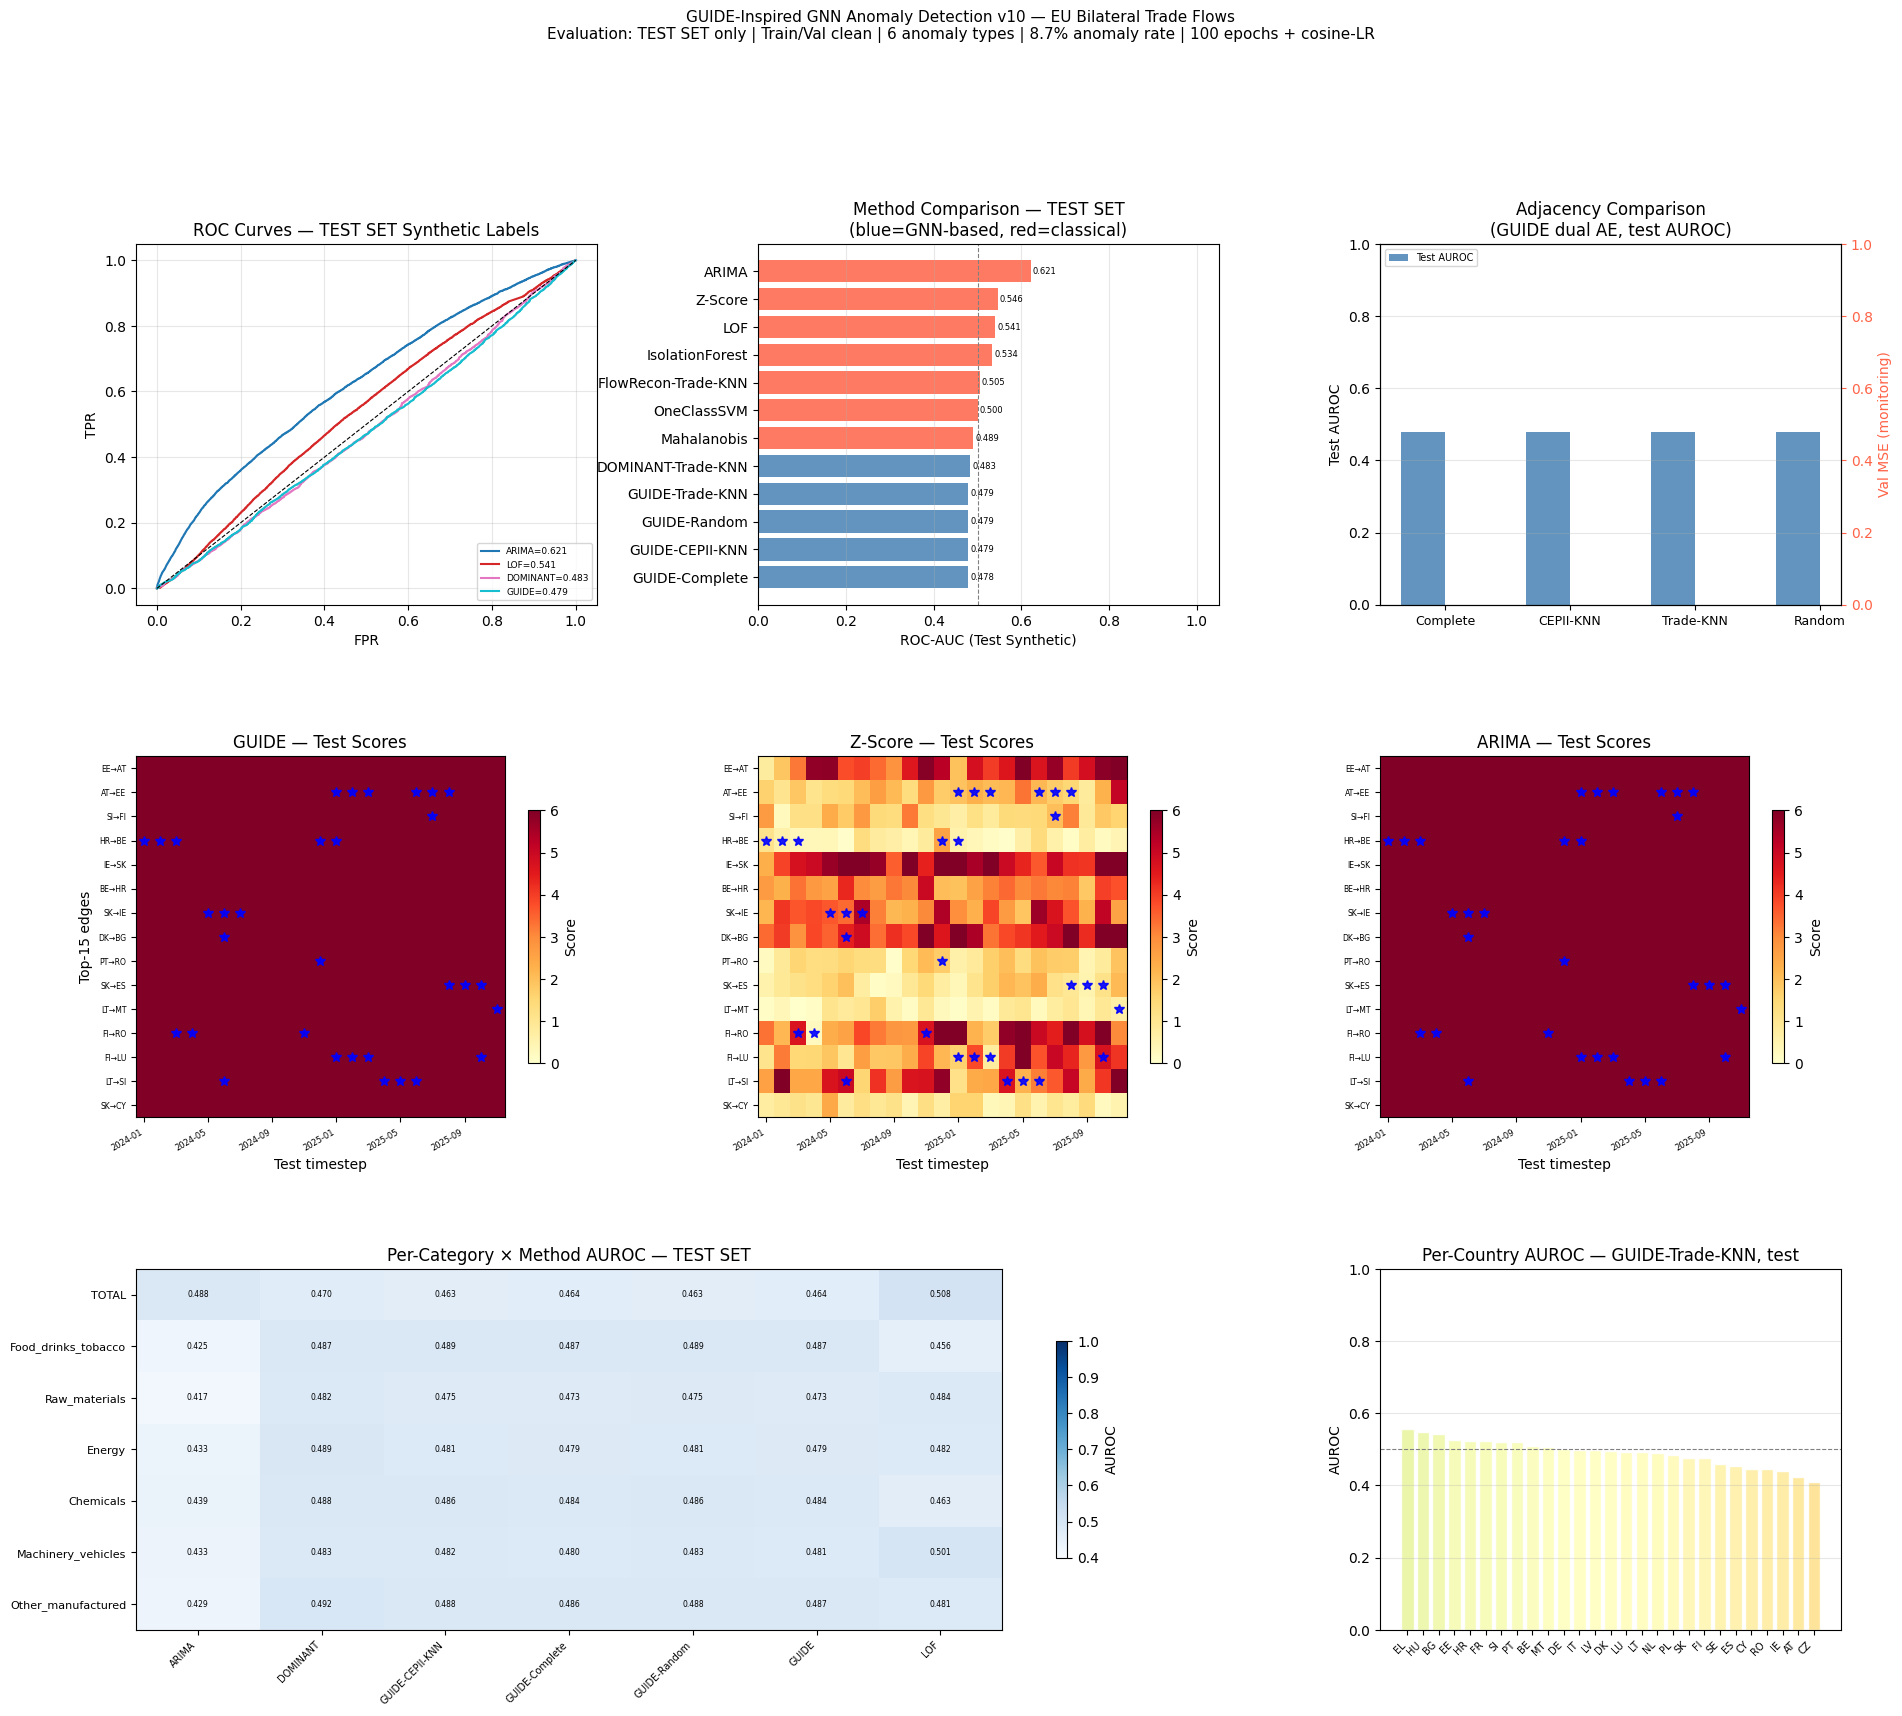

Saved: gnn_v10_guide_anomaly.png

✓ v10 complete


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell L — Visualisation (v11)
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── Plot 1: ROC curves ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(roc_curves)))
for (name, (fpr, tpr, auc)), col in zip(
        sorted(roc_curves.items(), key=lambda x: -(x[1][2] or 0)), colors_roc):
    short = name.replace(f"-{BEST_ADJ}","")
    ax1.plot(fpr, tpr, label=f"{short}={auc:.3f}", color=col, linewidth=1.5)
ax1.plot([0,1],[0,1],"k--", linewidth=0.8)
ax1.set_xlabel("FPR"); ax1.set_ylabel("TPR")
ax1.set_title("ROC Curves — TEST SET Synthetic Labels")
ax1.legend(fontsize=6.5, loc="lower right"); ax1.grid(alpha=0.3)

# ── Plot 2: Method comparison bar chart ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
guide_methods = [n for n in eval_all if "GUIDE" in n or "DOMINANT" in n]
class_methods = [n for n in eval_all if n not in guide_methods]
auroc_g = [(n, eval_all[n]["synth"]["auroc"] or 0) for n in guide_methods]
auroc_c = [(n, eval_all[n]["synth"]["auroc"] or 0) for n in class_methods]
all_sorted = sorted(auroc_g + auroc_c, key=lambda x: -x[1])
names_b = [n for n,_ in all_sorted]; vals_b = [v for _,v in all_sorted]
cols_b  = ["steelblue" if "GUIDE" in n or "DOMINANT" in n else "tomato" for n in names_b]
bars = ax2.barh(names_b[::-1], vals_b[::-1], color=cols_b[::-1], alpha=0.85)
ax2.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax2.set_xlabel("ROC-AUC (Test Synthetic)")
ax2.set_title("Method Comparison — TEST SET\n(blue=GNN-based, red=classical)")
ax2.set_xlim(0, 1.05); ax2.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, vals_b[::-1]):
    ax2.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=6)

# ── Plot 3: Adjacency comparison ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
adj_names = list(ADJ_CONFIGS.keys())
sa  = [adj_results[a]["synth"]["auroc"] or 0 for a in adj_names]
x   = np.arange(len(adj_names)); w = 0.35
ax3.bar(x - w/2, sa,  w, label="Test AUROC", color="steelblue", alpha=0.85)
ax3b = ax3.twinx()
ax3b.set_ylabel("Val MSE (monitoring)", color="tomato")
ax3b.tick_params(axis="y", colors="tomato")
ax3.set_xticks(x); ax3.set_xticklabels(adj_names, fontsize=9)
ax3.set_ylim(0, 1); ax3.set_ylabel("Test AUROC")
ax3.set_title("Adjacency Comparison\n(GUIDE dual AE, test AUROC)")
ax3.legend(loc="upper left", fontsize=7); ax3.grid(axis="y", alpha=0.3)

# ── Plots 4-6: Anomaly score heatmaps (test period) ──────────────────────────
top_edges = np.argsort(label_synth.sum(axis=(0,2)))[-15:][::-1]
for plot_i, (method_key, ax_pos) in enumerate([
        (f"GUIDE-{BEST_ADJ}", gs[1,0]),
        ("Z-Score",           gs[1,1]),
        ("ARIMA",            gs[1,2])]):
    axh = fig.add_subplot(ax_pos)
    sc_slice = all_scores[method_key][:, top_edges, 0]
    vmax = min(ANOMALY_THRESH*2, np.nanpercentile(sc_slice, 99))
    im   = axh.imshow(sc_slice.T, aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax)
    axh.set_xlabel("Test timestep")
    axh.set_ylabel("Top-15 edges" if plot_i==0 else "")
    edge_labs = [f"{COUNTRIES[edge_pairs[e][0]]}→{COUNTRIES[edge_pairs[e][1]]}"
                 for e in top_edges]
    axh.set_yticks(range(15)); axh.set_yticklabels(edge_labs, fontsize=5.5)
    test_dates = [common_time[t+1].strftime("%Y-%m") for t in test_idx]
    step = max(1, n_test//5)
    axh.set_xticks(range(0, n_test, step))
    axh.set_xticklabels(test_dates[::step], fontsize=6, rotation=30, ha="right")
    plt.colorbar(im, ax=axh, shrink=0.7, label="Score")
    axh.set_title(f"{method_key.replace(f'-{BEST_ADJ}','')} — Test Scores")
    # Mark injected anomalies
    for vi, e_idx, c_idx in synth_events:
        e_pos = list(top_edges).index(e_idx) if e_idx in top_edges else None
        if e_pos is not None and c_idx == 0:
            axh.plot(vi, e_pos, "b*", markersize=7, alpha=0.9)

# ── Plot 7: Per-category × Method AUROC heatmap ──────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
focus_methods = sorted([n for n in all_scores if
    any(k in n for k in ["GUIDE","DOMINANT","ARIMA","STL","Z-score","LOF","AE-MLP"])
    and all_scores[n].shape[0] == n_test])
cat_auc = np.full((N_CATS, len(focus_methods)), np.nan)
for mi, mname in enumerate(focus_methods):
    sc_arr = all_scores[mname]
    for ci, cat in enumerate(ALL_CATS):
        sc = sc_arr[:,:,ci].reshape(-1); lb = label_synth[:,:,ci].reshape(-1).astype(int)
        ok = ~np.isnan(sc)
        if lb[ok].sum() > 0:
            cat_auc[ci, mi] = roc_auc_score(lb[ok],
                                             np.clip(sc[ok],0,np.percentile(sc[ok],99.9)))
im5 = ax5.imshow(cat_auc, aspect="auto", cmap="Blues", vmin=0.4, vmax=1.0)
ax5.set_xticks(range(len(focus_methods)))
ax5.set_xticklabels([n.replace(f"-{BEST_ADJ}","") for n in focus_methods],
                    rotation=45, ha="right", fontsize=7)
ax5.set_yticks(range(N_CATS)); ax5.set_yticklabels(ALL_CATS, fontsize=8)
for ci in range(N_CATS):
    for mi in range(len(focus_methods)):
        if not np.isnan(cat_auc[ci,mi]):
            ax5.text(mi, ci, f"{cat_auc[ci,mi]:.3f}", ha="center", va="center", fontsize=5.5)
plt.colorbar(im5, ax=ax5, shrink=0.6, label="AUROC")
ax5.set_title("Per-Category × Method AUROC — TEST SET")

# ── Plot 8: Per-country AUROC ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
c_sorted = sorted(country_aucs.items(), key=lambda x: -(x[1] or 0))
c_names  = [c for c,_ in c_sorted]; c_vals = [v or 0 for _,v in c_sorted]
bar_c = plt.cm.RdYlGn(np.array(c_vals))
ax6.bar(c_names, c_vals, color=bar_c, alpha=0.9, edgecolor="white")
ax6.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax6.set_xticklabels(c_names, rotation=45, ha="right", fontsize=7)
ax6.set_ylim(0, 1); ax6.set_ylabel("AUROC")
ax6.set_title(f"Per-Country AUROC — GUIDE-{BEST_ADJ}, test")
ax6.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"GUIDE-Inspired GNN Anomaly Detection v10 — EU Bilateral Trade Flows\n"
    f"Evaluation: TEST SET only | Train/Val clean | 6 anomaly types | "
    f"{pct_anomalous:.1f}% anomaly rate | {RECON_EPOCHS} epochs + cosine-LR",
    fontsize=11, y=1.01
)
plt.savefig("gnn_v10_guide_anomaly.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: gnn_v10_guide_anomaly.png")
print("\n✓ v10 complete")
